I0000 00:00:1783513501.576520      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783513501.579453      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].


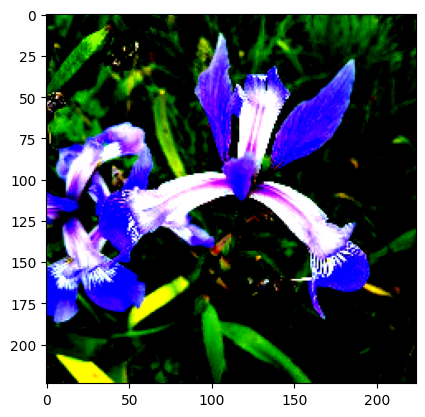

In [1]:
import tensorflow as tf
import torch
import torchvision
from torch.utils.data import IterableDataset, DataLoader
from matplotlib import pyplot as plt
import numpy as np
import torch.nn as nn
from PIL import Image
def parse_tfrecord(example_proto):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'class': tf.io.FixedLenFeature([], tf.int64),
        'id' : tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    image = tf.image.decode_jpeg(parsed['image'], channels=3)
    image = tf.image.resize(image, [224, 224])
    #image = tf.image.convert_image_dtype(image, tf.float32)
    label = parsed['class']
    idd = parsed['id']
    return image, label,idd

def load_tfrecord_dataset(pattern):
    files = tf.io.gfile.glob(pattern)
    if not files:
        raise ValueError(f"No files found for pattern {pattern}")
    dataset = tf.data.TFRecordDataset(files)
    dataset = dataset.map(parse_tfrecord)
    # 可选：打乱、批处理等，但此处我们只返回样本级别的数据集
    return dataset

class TFRecordToPyTorch(IterableDataset):
    def __init__(self, tfrecord_pattern,transform=None):
        self.tfrecord_pattern = tfrecord_pattern
        self.transform=transform

    def __iter__(self):
        # 每次迭代创建新的数据集，保证可重复使用
        dataset = load_tfrecord_dataset(self.tfrecord_pattern)
        # 使用 as_numpy_iterator() 获取 NumPy 数组，便于转换为 PyTorch 张量
        for image_np, label_np,idd in dataset.as_numpy_iterator():
            # image_np shape: (224,224,3), dtype float32, label_np scalar int64
            # 转为 PyTorch 张量，并调整为 CxHxW
            image_pil = Image.fromarray((image_np).astype('uint8')) 
            if self.transform:
                image_tensor = self.transform(image_pil)
            else:
                # 如果不需要 transform，至少转为 tensor
                image_tensor = torch.from_numpy(image_np).permute(2,0,1)
            #image_torch = torch.from_numpy(image_np).permute(2, 0, 1)  # (3,224,224)
            label_torch = torch.tensor(label_np, dtype=torch.long)
            id_torch = idd
            yield image_tensor, label_torch,id_torch

# 使用
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
tfrecord_path = '/kaggle/input/competitions/tpu-getting-started/tfrecords-jpeg-224x224/train/*'
dataset = TFRecordToPyTorch(tfrecord_path,transform)
tfrecord_path = '/kaggle/input/competitions/tpu-getting-started/tfrecords-jpeg-224x224/val/*'
dataset2 = TFRecordToPyTorch(tfrecord_path,transform)
# 可以配合 DataLoader 使用
train_dataloader = DataLoader(dataset, batch_size=32, num_workers=0)  # num_workers 设为0，因为 TF 数据集内部已并行
val_dataloader = DataLoader(dataset2, batch_size=32, num_workers=0)
for batch in train_dataloader:
    plt.imshow(batch[0][1].permute(1,2,0).numpy())
    break
    plt.axis('off')
    plt.show()

In [2]:
pretrained_net = torchvision.models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


In [3]:
pretrained_net.fc=nn.Linear(pretrained_net.fc.in_features,104)
nn.init.xavier_uniform_(pretrained_net.fc.weight)

Parameter containing:
tensor([[ 0.0391, -0.0359,  0.0388,  ..., -0.0067, -0.0466,  0.0074],
        [ 0.0360, -0.0080,  0.0314,  ...,  0.0155,  0.0126, -0.0466],
        [ 0.0393,  0.0281, -0.0347,  ...,  0.0169, -0.0164,  0.0289],
        ...,
        [-0.0022, -0.0320, -0.0400,  ..., -0.0068,  0.0455, -0.0202],
        [-0.0064,  0.0433,  0.0035,  ...,  0.0013, -0.0382,  0.0487],
        [ 0.0182,  0.0425,  0.0161,  ...,  0.0343, -0.0364,  0.0126]],
       requires_grad=True)

In [4]:
for parm in pretrained_net.conv1.parameters():
    parm.requires_grad=False
for parm in pretrained_net.bn1.parameters():
    parm.requires_grad=False
for parm in pretrained_net.layer1.parameters():
    parm.requires_grad=False
for parm in pretrained_net.layer2.parameters():
    parm.requires_grad=False
for parm in pretrained_net.layer3.parameters():
    parm.requires_grad=False

In [5]:
 def print_trainable_info(model):
        frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total = frozen + trainable
        print(f"  冻结参数: {frozen:,}  可训练参数: {trainable:,}  ({100.*trainable/total:.1f}%)")

In [6]:
print_trainable_info(pretrained_net)

  冻结参数: 8,543,296  可训练参数: 15,177,832  (64.0%)


In [7]:
@torch.no_grad()
def validate(model,loader):
    model.eval()
    acc=0
    total=0
    for batch in loader:
        X = batch[0]
        labels = batch[1]
        X = X.to(device)
        labels = labels.to(device)
        pred=torch.argmax(model(X),dim=1)
        acc+=pred.eq(labels).sum()
        total+=labels.size(0)
    print(f"acc:{acc/total}")

In [8]:
from tqdm import tqdm   
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pretrained_net=pretrained_net.to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(pretrained_net.parameters(), lr=2e-4)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
epochs = 20
for epoch in range(epochs):
    pretrained_net.train()
    training_loss = 0
    
    # 使用 tqdm 包装 dataloader，并设置描述信息
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}")
    lens=0
    for batch in progress_bar:
        optimizer.zero_grad()
        X = batch[0].to(device)
        labels = batch[1].to(device)
        
        outputs = pretrained_net(X)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()
        
        training_loss += loss.item()
        lens+=labels.size(0)
        # 更新进度条显示当前 batch 的损失
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'avg_loss': f'{training_loss / (progress_bar.n+1):.4f}'  # progress_bar.n 是已处理 batch 数
        })
    
    scheduler.step()
    
    # 计算平均训练损失（注意：len(train_dataloader) 才是 batch 总数）
    avg_train_loss = training_loss / lens
    print(f"Epoch {epoch+1} train_loss: {avg_train_loss:.4f}")
    
    # 验证（你也可以为验证添加进度条，见下方建议）
    validate(pretrained_net, val_dataloader)
    

Epoch 1/20: 399it [01:18,  5.06it/s, loss=1.0582, avg_loss=1.2128]


Epoch 1 train_loss: 0.0379
acc:0.8380926847457886


Epoch 2/20: 399it [01:18,  5.07it/s, loss=0.2247, avg_loss=0.2473]


Epoch 2 train_loss: 0.0077
acc:0.860722005367279


Epoch 3/20: 399it [01:18,  5.06it/s, loss=0.0718, avg_loss=0.0589]


...

Epoch 18 train_loss: 0.0000
acc:0.9119073152542114


Epoch 19/20: 399it [01:19,  5.05it/s, loss=0.0001, avg_loss=0.0001]


Epoch 19 train_loss: 0.0000
acc:0.912446141242981


Epoch 20/20: 399it [01:18,  5.08it/s, loss=0.0000, avg_loss=0.0000]


Epoch 20 train_loss: 0.0000
acc:0.9135236740112305


In [9]:
import pandas as pd
def parse_tfrecord_test(example_proto):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'id' : tf.io.FixedLenFeature([], tf.string)
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    image = tf.image.decode_jpeg(parsed['image'], channels=3)
    image = tf.image.resize(image, [224, 224])
    #image = tf.image.convert_image_dtype(image, tf.float32)
    idd = parsed['id']
    return image,idd
def load_tfrecord_dataset_test(pattern):
    files = tf.io.gfile.glob(pattern)
    if not files:
        raise ValueError(f"No files found for pattern {pattern}")
    dataset = tf.data.TFRecordDataset(files)
    dataset = dataset.map(parse_tfrecord_test)
    # 可选：打乱、批处理等，但此处我们只返回样本级别的数据集
    return dataset
class TFRecordToPyTorchTest(IterableDataset):
    def __init__(self, tfrecord_pattern,transform=None):
        self.tfrecord_pattern = tfrecord_pattern
        self.transform=transform

    def __iter__(self):
        # 每次迭代创建新的数据集，保证可重复使用
        dataset = load_tfrecord_dataset_test(self.tfrecord_pattern)
        # 使用 as_numpy_iterator() 获取 NumPy 数组，便于转换为 PyTorch 张量
        for image_np,idd in dataset.as_numpy_iterator():
            # image_np shape: (224,224,3), dtype float32, label_np scalar int64
            # 转为 PyTorch 张量，并调整为 CxHxW
            image_pil = Image.fromarray((image_np).astype('uint8')) 
            if self.transform:
                image_tensor = self.transform(image_pil)
            else:
                # 如果不需要 transform，至少转为 tensor
                image_tensor = torch.from_numpy(image_np).permute(2,0,1)
            #image_torch = torch.from_numpy(image_np).permute(2, 0, 1)  # (3,224,224)
            #label_torch = torch.tensor(label_np, dtype=torch.long)
            id_torch = idd
            yield image_tensor,id_torch
tfrecord_path = '/kaggle/input/competitions/tpu-getting-started/tfrecords-jpeg-224x224/test/*'
dataset3 = TFRecordToPyTorchTest(tfrecord_path,transform)
test_dataloader = DataLoader(dataset3, batch_size=32, num_workers=0)
id_array=[]
all_preds=[]
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch[0].to(device)
        idd = batch[1]
        outputs = pretrained_net(input_ids)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        id_array.extend(idd)
submission = pd.DataFrame({
    'id':id_array,
    'label': all_preds
})


In [10]:
submission['id'] = submission['id'].apply(lambda x: x.decode('utf-8'))
print(submission)
submission.to_csv('submission.csv', index=False)
print("Submission saved!")

             id  label
0     59d1b6146     46
1     48c96bd6b     15
2     7b437ba4e      9
3     1b7aef8e8     79
4     d6143b4d4      4
...         ...    ...
7377  2a608c0db    103
7378  d82a21bbd     93
7379  f9c931893     53
7380  18c7b92b8     41
7381  523df966b    102

[7382 rows x 2 columns]
Submission saved!
